# Comparaison des Méthodes d'Imputation pour la Prédiction de l'Âge

Ce notebook compare l'impact de différentes stratégies d'imputation des valeurs manquantes
sur la performance du meilleur modèle (ResidualLearningPipeline).

## Méthodes comparées
1. **Zero Fill** — Remplacement par 0 (worst-case baseline)
2. **Mean** — Imputation par la moyenne de chaque CpG (méthode actuelle)
3. **Median** — Imputation par la médiane de chaque CpG
4. **KNN (k=5)** — KNNImputer (distance euclidienne)
5. **Iterative/MICE** — IterativeImputer (BayesianRidge)

## Protocole
- Source : `Data/c_sample.csv` (données brutes avec NaN)
- Sélection : Top 500 CpG par corrélation absolue avec l'âge
- Modèle : ResidualLearningPipeline (5-fold CV)
- Métriques : MAE ± std, R² ± std

In [1]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.experimental import enable_iterative_imputer  # noqa

import numpy as np
import pandas as pd
from pathlib import Path
from time import time

from sklearn.linear_model import ElasticNetCV, LinearRegression, BayesianRidge
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path('Data')
TOP_K = 500
N_FOLDS = 5
CHUNK_SIZE = 5000

print('Imports OK')

Imports OK


## Définition du ResidualLearningPipeline

Pipeline hybride identique à celui utilisé dans `comparaison.ipynb`.

In [2]:
class ResidualLearningPipeline:
    """
    Pipeline hybride : ElasticNet (linéaire) + XGBoost (résidus) + Bias Correction.
    
    Étape 1 : ElasticNetCV -> prédiction linéaire P_lin
    Étape 2 : Résidus R = y - P_lin
    Étape 3 : XGBoost sur les features -> prédit R_hat
    Étape 4 : LinearRegression sur (P_lin, R_hat) -> prédiction finale corrigée
    """
    
    def __init__(
        self,
        enet_l1_ratios=(0.1, 0.3, 0.5, 0.7, 0.9),
        enet_n_alphas=50,
        enet_cv=5,
        top_k=500,
        xgb_n_estimators=300,
        xgb_max_depth=3,
        xgb_learning_rate=0.03,
        xgb_subsample=0.7,
        xgb_colsample_bytree=0.5,
        xgb_reg_alpha=10.0,
        xgb_reg_lambda=50.0,
        xgb_min_child_weight=10,
        xgb_early_stopping_rounds=30,
    ):
        self.enet_l1_ratios = enet_l1_ratios
        self.enet_n_alphas = enet_n_alphas
        self.enet_cv = enet_cv
        self.top_k = top_k
        
        self.xgb_params = dict(
            n_estimators=xgb_n_estimators,
            max_depth=xgb_max_depth,
            learning_rate=xgb_learning_rate,
            subsample=xgb_subsample,
            colsample_bytree=xgb_colsample_bytree,
            reg_alpha=xgb_reg_alpha,
            reg_lambda=xgb_reg_lambda,
            min_child_weight=xgb_min_child_weight,
            early_stopping_rounds=xgb_early_stopping_rounds,
            objective='reg:squarederror',
            eval_metric='mae',
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
        
        self.feature_idx_ = None
        self.enet_ = None
        self.xgb_ = None
        self.bias_corrector_ = None
    
    def _select_features(self, X_train, y_train):
        """Sélection top-k par corrélation (intra-fold)."""
        corrs = np.array([
            abs(np.corrcoef(X_train[:, j], y_train)[0, 1])
            for j in range(X_train.shape[1])
        ])
        corrs = np.nan_to_num(corrs, nan=0.0)
        k = min(self.top_k, len(corrs))
        self.feature_idx_ = np.argpartition(corrs, -k)[-k:]
        return X_train[:, self.feature_idx_]
    
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        X_scaled = self._select_features(X_train, y_train)
        
        self.enet_ = ElasticNetCV(
            l1_ratio=list(self.enet_l1_ratios),
            n_alphas=self.enet_n_alphas,
            cv=self.enet_cv,
            max_iter=50000,
            tol=1e-4,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        self.enet_.fit(X_scaled, y_train)
        P_lin = self.enet_.predict(X_scaled)
        
        residuals = y_train - P_lin
        
        self.xgb_ = XGBRegressor(**self.xgb_params)
        
        fit_params = {}
        if X_val is not None and y_val is not None:
            X_val_sel = X_val[:, self.feature_idx_]
            P_lin_val = self.enet_.predict(X_val_sel)
            residuals_val = y_val - P_lin_val
            fit_params['eval_set'] = [(X_val_sel, residuals_val)]
            fit_params['verbose'] = False
        else:
            fit_params['eval_set'] = [(X_scaled, residuals)]
            fit_params['verbose'] = False
        
        self.xgb_.fit(X_scaled, residuals, **fit_params)
        R_hat = self.xgb_.predict(X_scaled)
        
        meta_features = np.column_stack([P_lin, R_hat])
        self.bias_corrector_ = LinearRegression()
        self.bias_corrector_.fit(meta_features, y_train)
        
        return self
    
    def predict(self, X):
        X_sel = X[:, self.feature_idx_]
        P_lin = self.enet_.predict(X_sel)
        R_hat = self.xgb_.predict(X_sel)
        meta_features = np.column_stack([P_lin, R_hat])
        return self.bias_corrector_.predict(meta_features)

## Chargement des Données Brutes (avec NaN)

1. Charger les annotations (âge, sample IDs)
2. Calculer les corrélations CpG-âge par chunks sur `c_sample.csv` (NaN-tolerant)
3. Sélectionner les top-500 CpG
4. Charger uniquement ces 500 lignes depuis le fichier brut (en préservant les NaN)

In [3]:
# --- Charger annotations ---
ind = pd.read_csv(DATA_DIR / 'annot_projet.csv')
ind = ind.dropna(subset=['age', 'Sample_description']).copy()
ind['Sample_description'] = ind['Sample_description'].astype(str)
ind = ind.set_index('Sample_description')

# --- Identifier les échantillons communs ---
raw_path = DATA_DIR / 'c_sample.csv'
sample_header = pd.read_csv(raw_path, nrows=0)
all_sample_ids = list(sample_header.columns)
common_ids = [s for s in all_sample_ids if s in ind.index]
y = ind.loc[common_ids, 'age'].values.astype(np.float32)
print(f'Échantillons communs : {len(common_ids)}, âge moyen : {y.mean():.1f} +/- {y.std():.1f}')

# --- Corrélations NaN-tolerant par chunks sur données brutes ---
print(f'\nCalcul des corrélations par chunks sur données brutes...')
t0 = time()
y_centered = y - y.mean()
y_den = np.sqrt(np.sum(y_centered ** 2))

all_corrs = []
for chunk in pd.read_csv(raw_path, usecols=common_ids, chunksize=CHUNK_SIZE):
    x = chunk.to_numpy(dtype=np.float32)
    if np.isnan(x).any():
        row_means = np.nanmean(x, axis=1, keepdims=True)
        row_means = np.where(np.isnan(row_means), 0, row_means)
        x = np.where(np.isnan(x), row_means, x)
    x_c = x - x.mean(axis=1, keepdims=True)
    num = x_c @ y_centered
    den = np.sqrt(np.sum(x_c ** 2, axis=1)) * y_den
    corr = np.divide(num, den, out=np.zeros_like(num), where=den != 0)
    all_corrs.append(np.abs(corr))

all_corrs = np.concatenate(all_corrs)
top_indices = np.argsort(all_corrs)[::-1]
top_k_indices = top_indices[:TOP_K]

print(f'  Corrélations calculées en {time()-t0:.1f}s')
print(f'  Top {TOP_K} : corr max={all_corrs[top_k_indices[0]]:.4f}, min={all_corrs[top_k_indices[-1]]:.4f}')

Échantillons communs : 400, âge moyen : 53.0 +/- 21.2

Calcul des corrélations par chunks sur données brutes...


KeyboardInterrupt: 

In [ ]:
# --- Charger uniquement les top-k CpG depuis données brutes (NaN préservés) ---
print(f'Chargement des top {TOP_K} CpG depuis données brutes (NaN préservés)...')
t0 = time()
indices_to_load = np.sort(top_k_indices)
rows = []
start = 0
for chunk in pd.read_csv(raw_path, usecols=common_ids, chunksize=CHUNK_SIZE):
    end = start + len(chunk)
    pos_s = np.searchsorted(indices_to_load, start)
    pos_e = np.searchsorted(indices_to_load, end)
    local = indices_to_load[pos_s:pos_e] - start
    if len(local) > 0:
        rows.append(chunk.iloc[local].values)
    start = end

X_raw = np.vstack(rows).T.astype(np.float32)  # (n_samples, TOP_K)

# Réordonner pour correspondre à l'ordre trié par corrélation
load_order = {idx: pos for pos, idx in enumerate(indices_to_load)}
reorder = np.array([load_order[i] for i in top_k_indices])
X_raw = X_raw[:, reorder]

nan_count = np.isnan(X_raw).sum()
nan_pct = 100 * nan_count / X_raw.size
print(f'  Chargé en {time()-t0:.1f}s, shape={X_raw.shape}')
print(f'  NaN : {nan_count} ({nan_pct:.2f}%)')
print(f'  NaN par échantillon : min={np.isnan(X_raw).sum(axis=1).min()}, '
      f'max={np.isnan(X_raw).sum(axis=1).max()}, '
      f'mean={np.isnan(X_raw).sum(axis=1).mean():.1f}')
print(f'  NaN par CpG : min={np.isnan(X_raw).sum(axis=0).min()}, '
      f'max={np.isnan(X_raw).sum(axis=0).max()}, '
      f'mean={np.isnan(X_raw).sum(axis=0).mean():.1f}')

Chargement des top 500 CpG depuis données brutes (NaN préservés)...


  Chargé en 29.1s, shape=(400, 500)
  NaN : 2069 (1.03%)
  NaN par échantillon : min=0, max=413, mean=5.2
  NaN par CpG : min=0, max=51, mean=4.1


## Application des Méthodes d'Imputation

Chaque méthode est appliquée à la matrice (400 x 500) contenant les NaN.

In [ ]:
imputation_methods = {
    '1. Zero Fill': lambda X: np.nan_to_num(X, nan=0.0),
    '2. Mean': lambda X: SimpleImputer(strategy='mean').fit_transform(X),
    '3. Median': lambda X: SimpleImputer(strategy='median').fit_transform(X),
    '4. KNN (k=5)': lambda X: KNNImputer(n_neighbors=5, weights='uniform').fit_transform(X),
    '5. Iterative (MICE)': lambda X: IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=10,
        random_state=RANDOM_STATE,
        skip_complete=True,
    ).fit_transform(X),
}

imputed_datasets = {}
print(f'Application des méthodes d\'imputation sur X_raw {X_raw.shape}...\n')

for name, impute_fn in imputation_methods.items():
    t0 = time()
    X_imputed = impute_fn(X_raw.copy()).astype(np.float32)
    dt = time() - t0
    remaining_nan = np.isnan(X_imputed).sum()
    imputed_datasets[name] = X_imputed
    print(f'  {name:<25s} | {dt:6.2f}s | NaN restants: {remaining_nan}')

print(f'\n{len(imputed_datasets)} datasets imputés prêts.')

Application des méthodes d'imputation sur X_raw (400, 500)...

  1. Zero Fill              |   0.00s | NaN restants: 0
  2. Mean                   |   0.00s | NaN restants: 0
  3. Median                 |   0.01s | NaN restants: 0
  4. KNN (k=5)              |   0.07s | NaN restants: 0


  5. Iterative (MICE)       | 1086.09s | NaN restants: 0

5 datasets imputés prêts.


## Cross-Validation (5-Fold) avec ResidualLearningPipeline

Les mêmes folds sont utilisés pour toutes les méthodes d'imputation,
ce qui permet une comparaison appariée et un test statistique valide.

In [ ]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

results = {name: {'mae': [], 'r2': [], 'rmse': []} for name in imputed_datasets}

print(f"{'='*70}")
print(f'  Cross-Validation {N_FOLDS}-Fold avec ResidualLearningPipeline')
print(f"{'='*70}")

for fold_i, (train_idx, test_idx) in enumerate(kf.split(y)):
    print(f"\n{'='*55}")
    print(f'  Fold {fold_i + 1}/{N_FOLDS}  (train={len(train_idx)}, test={len(test_idx)})')
    print(f"{'='*55}")
    
    y_train, y_test = y[train_idx], y[test_idx]
    
    for method_name, X_imputed in imputed_datasets.items():
        t0 = time()
        X_train = X_imputed[train_idx]
        X_test = X_imputed[test_idx]
        
        pipeline = ResidualLearningPipeline(
            top_k=TOP_K,
            xgb_n_estimators=300,
            xgb_max_depth=3,
            xgb_learning_rate=0.03,
            xgb_subsample=0.7,
            xgb_colsample_bytree=0.5,
            xgb_reg_alpha=10.0,
            xgb_reg_lambda=50.0,
            xgb_min_child_weight=10,
            xgb_early_stopping_rounds=30,
            enet_cv=3,
        )
        pipeline.fit(X_train, y_train, X_val=X_test, y_val=y_test)
        y_pred = pipeline.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        results[method_name]['mae'].append(mae)
        results[method_name]['r2'].append(r2)
        results[method_name]['rmse'].append(rmse)
        
        dt = time() - t0
        print(f'  {method_name:<25s} | MAE={mae:.3f} | R2={r2:.3f} | {dt:.1f}s')

print(f"\n{'='*70}")
print('Cross-validation terminée.')

  Cross-Validation 5-Fold avec ResidualLearningPipeline

  Fold 1/5  (train=320, test=80)


  1. Zero Fill              | MAE=2.927 | R2=0.968 | 1.7s


  2. Mean                   | MAE=3.193 | R2=0.961 | 1.8s


  3. Median                 | MAE=3.233 | R2=0.961 | 1.8s


  4. KNN (k=5)              | MAE=2.845 | R2=0.969 | 1.8s


...

  1. Zero Fill              | MAE=3.170 | R2=0.938 | 1.6s


  2. Mean                   | MAE=3.059 | R2=0.952 | 1.6s


  3. Median                 | MAE=2.988 | R2=0.953 | 1.5s


  4. KNN (k=5)              | MAE=3.417 | R2=0.924 | 1.3s


  5. Iterative (MICE)       | MAE=2.917 | R2=0.967 | 1.5s

Cross-validation terminée.


## Tableau Comparatif des Résultats

In [ ]:
summary_rows = []
for name, scores in results.items():
    mae_arr = np.array(scores['mae'])
    r2_arr = np.array(scores['r2'])
    rmse_arr = np.array(scores['rmse'])
    summary_rows.append({
        'Méthode': name,
        'MAE_mean': mae_arr.mean(),
        'MAE_std': mae_arr.std(),
        'R2_mean': r2_arr.mean(),
        'R2_std': r2_arr.std(),
        'RMSE_mean': rmse_arr.mean(),
        'RMSE_std': rmse_arr.std(),
    })

df_summary = pd.DataFrame(summary_rows).sort_values('MAE_mean')

print(f"\n{'='*80}")
print(f"  COMPARAISON DES MÉTHODES D'IMPUTATION ({N_FOLDS}-fold CV)")
print(f'  Modèle: ResidualLearningPipeline | Features: Top {TOP_K} CpG')
print(f"{'='*80}")
print(f"{'Méthode':<25s} | {'MAE (ans)':<15s} | {'R²':<15s} | {'RMSE':<15s}")
print(f"{'-'*25}-+-{'-'*15}-+-{'-'*15}-+-{'-'*15}")

for _, row in df_summary.iterrows():
    print(f"{row['Méthode']:<25s} | "
          f"{row['MAE_mean']:.3f} ± {row['MAE_std']:.3f}  | "
          f"{row['R2_mean']:.3f} ± {row['R2_std']:.3f}  | "
          f"{row['RMSE_mean']:.3f} ± {row['RMSE_std']:.3f}")

best_name = df_summary.iloc[0]['Méthode']
best_mae = df_summary.iloc[0]['MAE_mean']
print(f'\n  -> Meilleure méthode : {best_name} (MAE = {best_mae:.3f} ans)')

results_path = Path('results/imputation_comparison_results.csv')
results_path.parent.mkdir(parents=True, exist_ok=True)
df_summary.to_csv(results_path, index=False)
print(f'  Résultats sauvegardés : {results_path}')


  COMPARAISON DES MÉTHODES D'IMPUTATION (5-fold CV)
  Modèle: ResidualLearningPipeline | Features: Top 500 CpG
Méthode                   | MAE (ans)       | R²              | RMSE           
--------------------------+-----------------+-----------------+----------------
5. Iterative (MICE)       | 3.192 ± 0.266  | 0.946 ± 0.025  | 4.798 ± 1.061
4. KNN (k=5)              | 3.410 ± 0.338  | 0.921 ± 0.040  | 5.706 ± 1.347
3. Median                 | 3.436 ± 0.301  | 0.924 ± 0.034  | 5.641 ± 1.120
2. Mean                   | 3.450 ± 0.279  | 0.925 ± 0.032  | 5.641 ± 1.067
1. Zero Fill              | 3.472 ± 0.409  | 0.920 ± 0.029  | 5.814 ± 1.075

  -> Meilleure méthode : 5. Iterative (MICE) (MAE = 3.192 ans)
  Résultats sauvegardés : results/imputation_comparison_results.csv


## Tests Statistiques (Paired t-test)

Comparaison appariée de chaque méthode avec la baseline (Mean imputation).

In [ ]:
baseline_name = '2. Mean'
baseline_mae = np.array(results[baseline_name]['mae'])

print(f'Tests appariés contre la baseline ({baseline_name}) :\n')
print(f"{'Méthode':<25s} | {'Delta MAE':>10s} | {'t-stat':>8s} | {'p-value':>8s} | {'Significatif':>12s}")
print(f"{'-'*25}-+-{'-'*10}-+-{'-'*8}-+-{'-'*8}-+-{'-'*12}")

for name, scores in results.items():
    if name == baseline_name:
        continue
    mae_arr = np.array(scores['mae'])
    delta = mae_arr.mean() - baseline_mae.mean()
    t_stat, p_value = stats.ttest_rel(mae_arr, baseline_mae)
    sig = 'Oui *' if p_value < 0.05 else 'Non'
    print(f'{name:<25s} | {delta:>+10.3f} | {t_stat:>8.3f} | {p_value:>8.4f} | {sig:>12s}')

Tests appariés contre la baseline (2. Mean) :

Méthode                   |  Delta MAE |   t-stat |  p-value | Significatif
--------------------------+------------+----------+----------+-------------
1. Zero Fill              |     +0.023 |    0.227 |   0.8312 |          Non
3. Median                 |     -0.014 |   -0.446 |   0.6784 |          Non
4. KNN (k=5)              |     -0.039 |   -0.305 |   0.7754 |          Non
5. Iterative (MICE)       |     -0.258 |   -3.455 |   0.0259 |        Oui *


## Visualisations

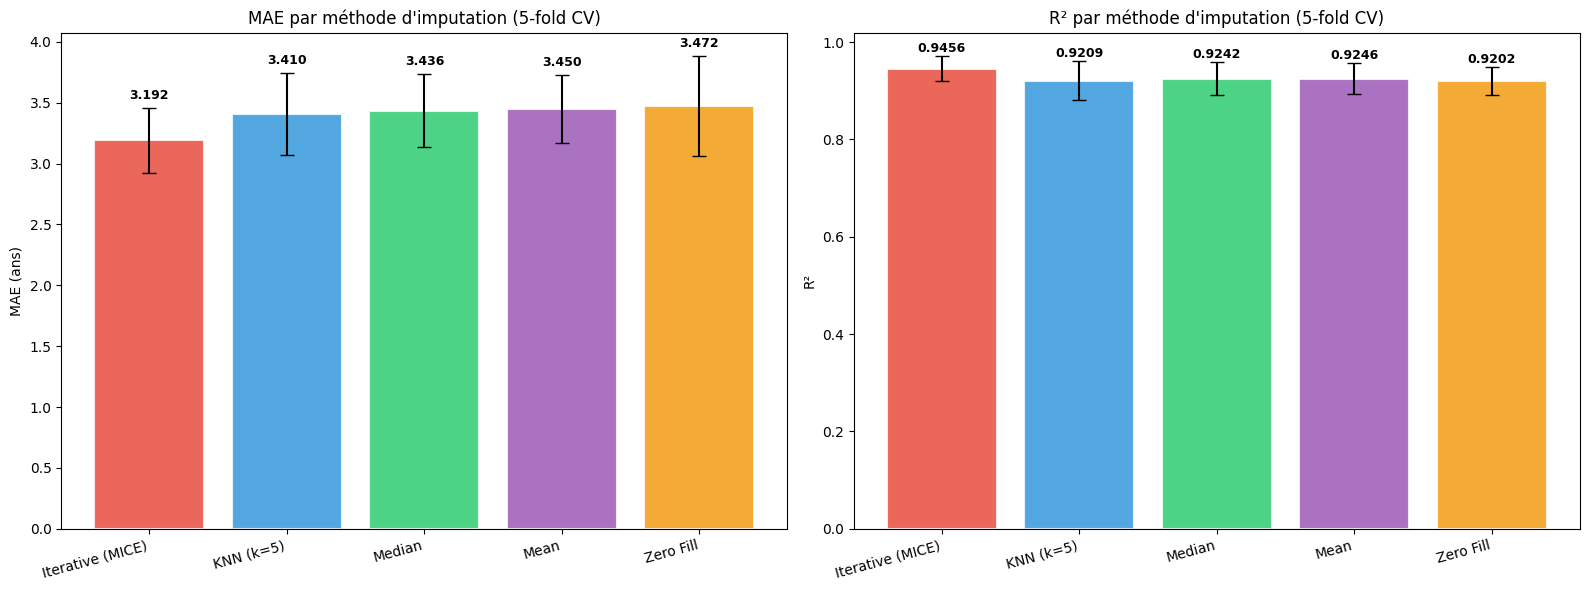

Figure sauvegardée : results/imputation_comparison_metrics.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods = df_summary['Méthode'].tolist()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']

# --- MAE ---
ax = axes[0]
mae_means = df_summary['MAE_mean'].values
mae_stds = df_summary['MAE_std'].values
bars = ax.bar(range(len(methods)), mae_means, yerr=mae_stds, capsize=5,
              color=colors[:len(methods)], alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels([m.split('. ')[1] for m in methods], rotation=15, ha='right')
ax.set_ylabel('MAE (ans)')
ax.set_title(f"MAE par méthode d'imputation ({N_FOLDS}-fold CV)")
for bar, mean, std in zip(bars, mae_means, mae_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.05,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- R² ---
ax = axes[1]
r2_means = df_summary['R2_mean'].values
r2_stds = df_summary['R2_std'].values
bars = ax.bar(range(len(methods)), r2_means, yerr=r2_stds, capsize=5,
              color=colors[:len(methods)], alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels([m.split('. ')[1] for m in methods], rotation=15, ha='right')
ax.set_ylabel('R²')
ax.set_title(f"R² par méthode d'imputation ({N_FOLDS}-fold CV)")
for bar, mean, std in zip(bars, r2_means, r2_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.002,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('results/imputation_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : results/imputation_comparison_metrics.png')

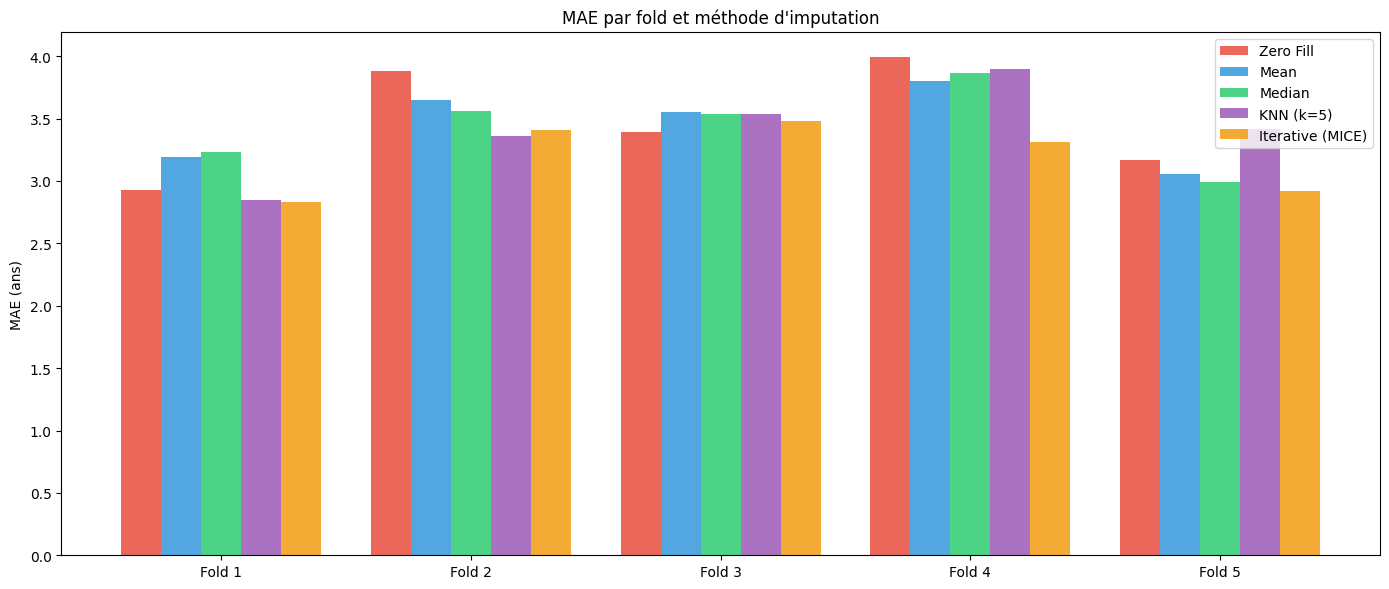

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(N_FOLDS)
n_methods = len(results)
width = 0.8 / n_methods
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']

for i, (name, scores) in enumerate(results.items()):
    offset = (i - n_methods/2 + 0.5) * width
    label = name.split('. ')[1]
    ax.bar(x + offset, scores['mae'], width, label=label,
           color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.set_ylabel('MAE (ans)')
ax.set_title("MAE par fold et méthode d'imputation")
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('results/imputation_comparison_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()

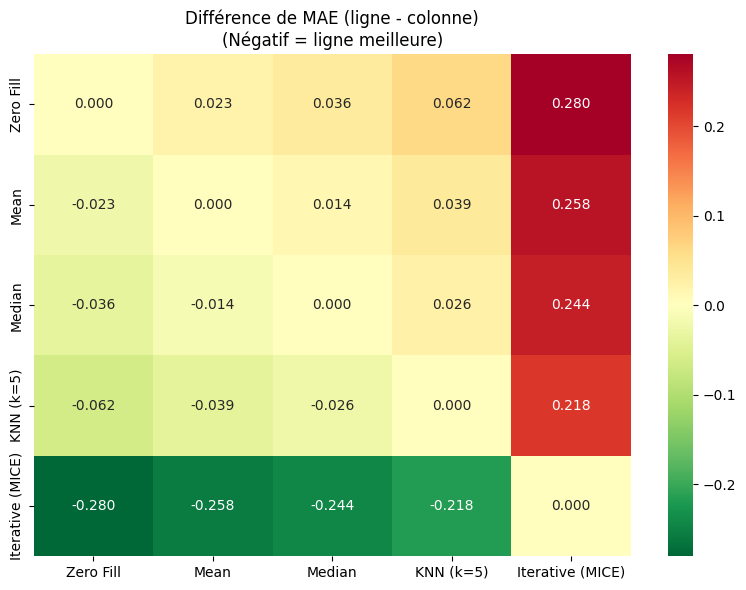

In [ ]:
method_names_short = [m.split('. ')[1] for m in results.keys()]
mae_matrix = np.array([results[m]['mae'] for m in results.keys()])

n_m = len(method_names_short)
diff_matrix = np.zeros((n_m, n_m))
for i in range(n_m):
    for j in range(n_m):
        diff_matrix[i, j] = mae_matrix[i].mean() - mae_matrix[j].mean()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(diff_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
            xticklabels=method_names_short, yticklabels=method_names_short,
            center=0, ax=ax)
ax.set_title('Différence de MAE (ligne - colonne)\n(Négatif = ligne meilleure)')
plt.tight_layout()
plt.savefig('results/imputation_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Analyse des Valeurs Manquantes

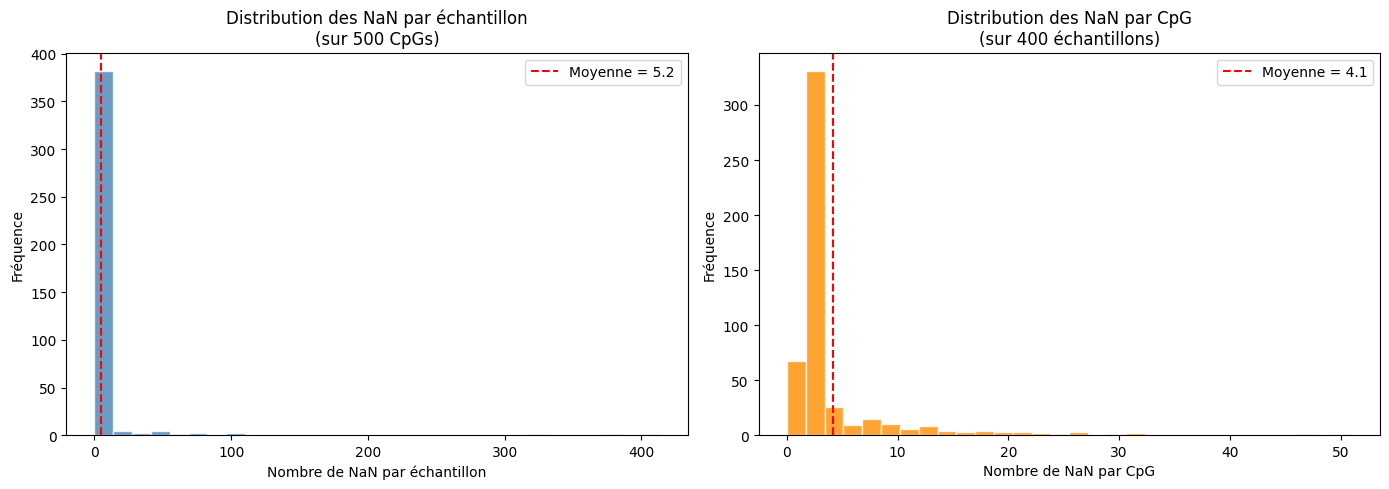

Total NaN: 2069 / 200000 (1.03%)
Échantillons sans NaN: 289
CpG sans NaN: 9


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nan_per_sample = np.isnan(X_raw).sum(axis=1)
ax = axes[0]
ax.hist(nan_per_sample, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel('Nombre de NaN par échantillon')
ax.set_ylabel('Fréquence')
ax.set_title(f'Distribution des NaN par échantillon\n(sur {TOP_K} CpGs)')
ax.axvline(nan_per_sample.mean(), color='red', linestyle='--',
           label=f'Moyenne = {nan_per_sample.mean():.1f}')
ax.legend()

nan_per_cpg = np.isnan(X_raw).sum(axis=0)
ax = axes[1]
ax.hist(nan_per_cpg, bins=30, color='darkorange', alpha=0.8, edgecolor='white')
ax.set_xlabel('Nombre de NaN par CpG')
ax.set_ylabel('Fréquence')
ax.set_title(f'Distribution des NaN par CpG\n(sur {len(common_ids)} échantillons)')
ax.axvline(nan_per_cpg.mean(), color='red', linestyle='--',
           label=f'Moyenne = {nan_per_cpg.mean():.1f}')
ax.legend()

plt.tight_layout()
plt.savefig('results/imputation_nan_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total NaN: {np.isnan(X_raw).sum()} / {X_raw.size} ({100*np.isnan(X_raw).sum()/X_raw.size:.2f}%)')
print(f'Échantillons sans NaN: {(nan_per_sample == 0).sum()}')
print(f'CpG sans NaN: {(nan_per_cpg == 0).sum()}')

## Conclusion

In [ ]:
print('=' * 75)
print('  RÉSUMÉ FINAL')
print('=' * 75)
print(f'\n  Dataset : {len(common_ids)} échantillons x {TOP_K} CpG (top par corrélation)')
print(f'  NaN : {np.isnan(X_raw).sum()} ({100*np.isnan(X_raw).sum()/X_raw.size:.2f}%)')
print(f'  Modèle : ResidualLearningPipeline (ElasticNetCV + XGBoost + Bias Correction)')
print(f'  Validation : {N_FOLDS}-fold CV\n')

print(df_summary[['Méthode', 'MAE_mean', 'MAE_std', 'R2_mean', 'R2_std']].to_string(index=False))

best = df_summary.iloc[0]
worst = df_summary.iloc[-1]
delta = worst['MAE_mean'] - best['MAE_mean']

print(f"\n  Meilleure : {best['Méthode']} (MAE = {best['MAE_mean']:.3f} ± {best['MAE_std']:.3f})")
print(f"  Pire      : {worst['Méthode']} (MAE = {worst['MAE_mean']:.3f} ± {worst['MAE_std']:.3f})")
print(f'  Écart max : {delta:.3f} ans')
print(f"\n{'='*75}")

  RÉSUMÉ FINAL

  Dataset : 400 échantillons x 500 CpG (top par corrélation)
  NaN : 2069 (1.03%)
  Modèle : ResidualLearningPipeline (ElasticNetCV + XGBoost + Bias Correction)
  Validation : 5-fold CV

            Méthode  MAE_mean  MAE_std  R2_mean   R2_std
5. Iterative (MICE)  3.191963 0.265664 0.945573 0.024791
       4. KNN (k=5)  3.410252 0.337568 0.920870 0.039763
          3. Median  3.435899 0.300562 0.924218 0.033776
            2. Mean  3.449612 0.279115 0.924559 0.031850
       1. Zero Fill  3.472225 0.408515 0.920195 0.028959

  Meilleure : 5. Iterative (MICE) (MAE = 3.192 ± 0.266)
  Pire      : 1. Zero Fill (MAE = 3.472 ± 0.409)
  Écart max : 0.280 ans

